 GOLD NANOSPHERE FDTD SIMULATION
Sphere radius      : 25.0 nm
Sphere diameter    : 50.0 nm
Medium refractive index : 1.33
Wavelength range   : 450–750 nm
Resolution         : 80 pixels/um
Cell size          : 690.0 nm

Generating geometry check...
     sphere, center = (0,0,0)
          radius 0.025
          dielectric constant epsilon diagonal = (1,1,1)


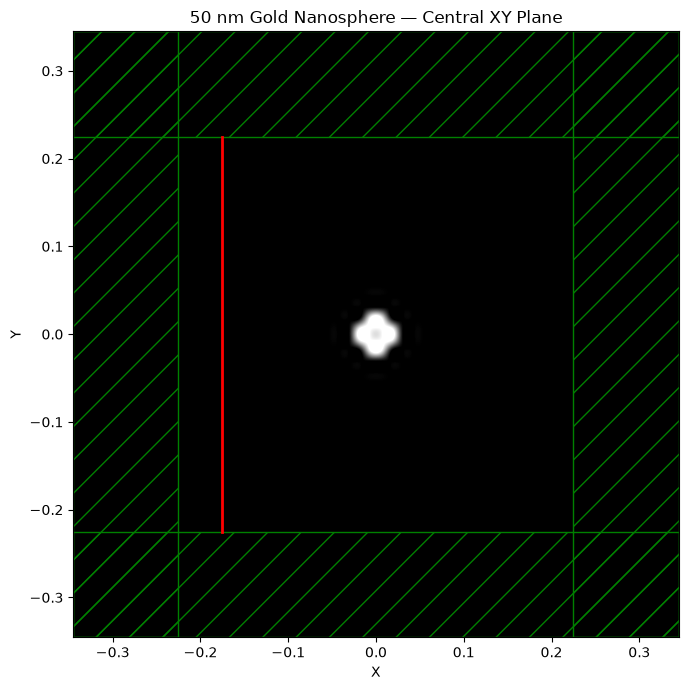


Starting FDTD simulation...
This may take several minutes depending on your CPU/RAM.

-----------
Initializing structure...
time for choose_chunkdivision = 0.00281191 s
Working in 3D dimensions.
Computational cell is 0.6875 x 0.6875 x 0.6875 with resolution 80
     sphere, center = (0,0,0)
          radius 0.025
          dielectric constant epsilon diagonal = (1,1,1)
time for set_epsilon = 1.41687 s
lorentzian susceptibility: frequency=10.7433, gamma=1.78571
lorentzian susceptibility: frequency=3.47141, gamma=2.01155
lorentzian susceptibility: frequency=2.39466, gamma=0.701702
lorentzian susceptibility: frequency=0.66944, gamma=0.278261
lorentzian susceptibility: frequency=0.33472, gamma=0.19438
drude susceptibility: frequency=1e-10, gamma=0.0427474
-----------
on time step 5 (time=0.025), 0.803345 s/step
on time step 108 (time=0.54), 0.0391848 s/step
on time step 217 (time=1.085), 0.0370422 s/step
on time step 325 (time=1.625), 0.0371502 s/step
on time step 434 (time=2.17), 0.036956

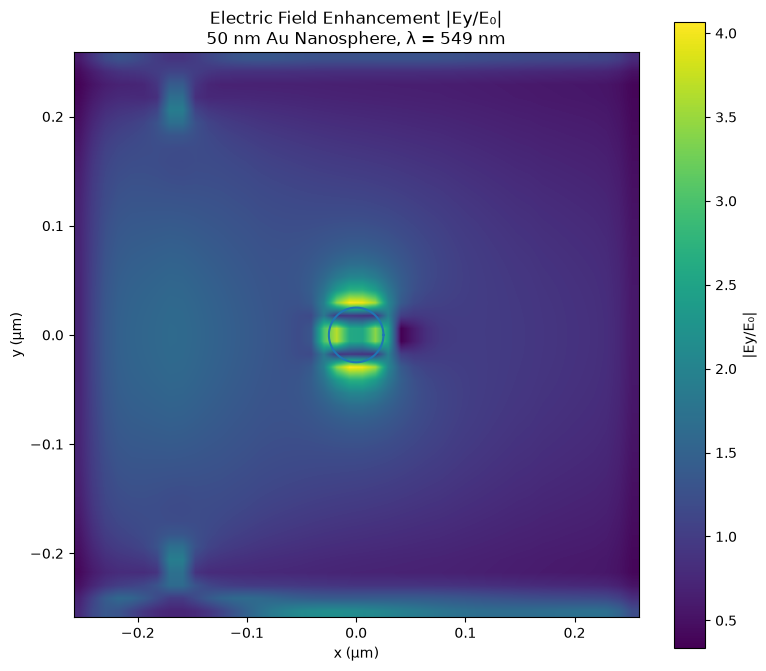


 NEAR-FIELD RESULT
Maximum |E/E0| at 548.8 nm:
4.067
Maximum |E/E0|²:
16.540

Calculating local field spectrum...


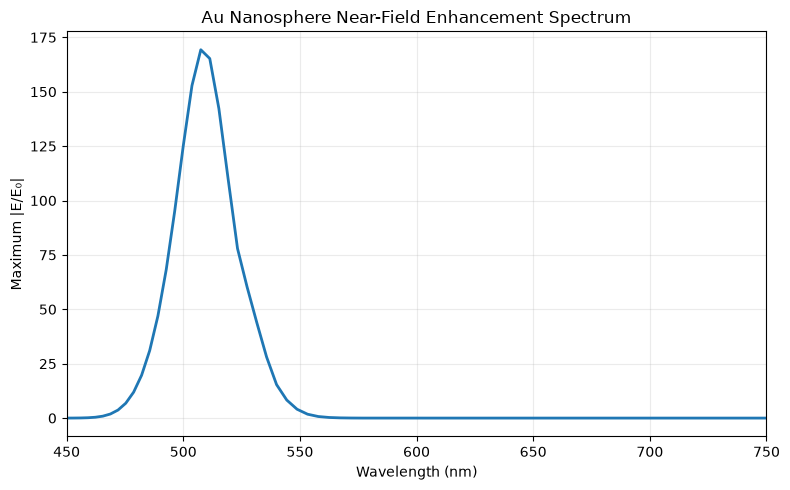


 SURFACE PLASMON RESULT
Estimated near-field resonance: 507.5 nm
Maximum near-field enhancement: 169.299
Maximum intensity enhancement: 28661.999
 Simulation completed successfully.


In [3]:
# ================================================================
# 3-D FDTD SIMULATION OF A GOLD NANOSPHERE
# Surface Plasmon Resonance / Near-Field Enhancement
# ================================================================

import meep as mp
import numpy as np
import matplotlib.pyplot as plt
from meep.materials import Au

# ------------------------------------------------
# 1. BASIC PARAMETERS
# ------------------------------------------------

# Meep length unit = 1 micron
# Gold sphere diameter = 50 nm
radius = 0.025          # 25 nm = 0.025 um

# Surrounding medium: water
n_medium = 1.33
epsilon_medium = n_medium**2

# Visible wavelength range
lambda_min = 0.45       # 450 nm
lambda_max = 0.75       # 750 nm

# Central wavelength
lambda0 = 0.55         # 550 nm

# Frequencies in Meep units
fmin = 1 / lambda_max
fmax = 1 / lambda_min
fcen = 1 / lambda0
fwidth = fmax - fmin

# ------------------------------------------------
# 2. SIMULATION CELL
# ------------------------------------------------

# PML thickness
dpml = 0.12             # 120 nm

# Air/water space around particle
air_buffer = 0.20       # 200 nm

# Cell size
cell_length = 2 * (radius + air_buffer + dpml)

cell_size = mp.Vector3(
    cell_length,
    cell_length,
    cell_length
)

# ------------------------------------------------
# 3. NUMERICAL RESOLUTION
# ------------------------------------------------

# pixels per micron
resolution = 80

print("==========================================")
print(" GOLD NANOSPHERE FDTD SIMULATION")
print("==========================================")
print(f"Sphere radius      : {radius*1000:.1f} nm")
print(f"Sphere diameter    : {2*radius*1000:.1f} nm")
print(f"Medium refractive index : {n_medium}")
print(f"Wavelength range   : {lambda_min*1000:.0f}–{lambda_max*1000:.0f} nm")
print(f"Resolution         : {resolution} pixels/um")
print(f"Cell size          : {cell_length*1000:.1f} nm")
print("==========================================")

# ------------------------------------------------
# 4. GOLD NANOSPHERE GEOMETRY
# ------------------------------------------------

geometry = [
    mp.Sphere(
        radius=radius,
        center=mp.Vector3(0, 0, 0),
        material=Au
    )
]

# ------------------------------------------------
# 5. BROADBAND PLANE-WAVE SOURCE
# ------------------------------------------------

# Propagation along +x
# Electric field polarized along y

source_x = -0.5 * cell_length + dpml + 0.05

sources = [
    mp.Source(
        src=mp.GaussianSource(
            frequency=fcen,
            fwidth=fwidth,
            cutoff=4
        ),
        component=mp.Ey,
        center=mp.Vector3(source_x, 0, 0),
        size=mp.Vector3(
            0,
            cell_length - 2*dpml,
            cell_length - 2*dpml
        )
    )
]

# ------------------------------------------------
# 6. MEEP SIMULATION
# ------------------------------------------------

sim = mp.Simulation(
    cell_size=cell_size,
    boundary_layers=[
        mp.PML(dpml)
    ],
    geometry=geometry,
    sources=sources,
    resolution=resolution,

    # Water as background
    default_material=mp.Medium(
        epsilon=epsilon_medium
    ),

    # Courant factor for stability with dispersive Au
    Courant=0.4
)

# ------------------------------------------------
# 7. GEOMETRY VISUALIZATION
# ------------------------------------------------

print("\nGenerating geometry check...")

fig, ax = plt.subplots(figsize=(7, 7))

output_plane = mp.Volume(
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(
        cell_length,
        cell_length,
        0
    )
)

sim.plot2D(
    ax=ax,
    output_plane=output_plane
)

ax.set_title(
    "50 nm Gold Nanosphere — Central XY Plane"
)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 8. FREQUENCY-DOMAIN FIELD MONITOR
# ------------------------------------------------

nfreq = 61

monitor = sim.add_dft_fields(
    [mp.Ey],
    fmin,
    fmax,
    nfreq,
    center=mp.Vector3(0, 0, 0),
    size=mp.Vector3(
        cell_length * 0.75,
        cell_length * 0.75,
        0
    )
)

# ------------------------------------------------
# 9. RUN FDTD
# ------------------------------------------------

print("\nStarting FDTD simulation...")
print("This may take several minutes depending on your CPU/RAM.")
print("")

sim.run(
    until_after_sources=mp.stop_when_fields_decayed(
        50,
        mp.Ey,
        mp.Vector3(0, 0, 0),
        1e-6
    )
)

print("\n==========================================")
print(" FDTD SIMULATION FINISHED")
print("==========================================")

# ------------------------------------------------
# 10. EXTRACT DFT FIELD
# ------------------------------------------------

print("\nExtracting frequency-domain electric fields...")

# Coordinates of the monitored plane
field = sim.get_dft_array(
    monitor,
    mp.Ey,
    0
)

field = np.asarray(field)

print("Field array shape:", field.shape)

# ------------------------------------------------
# 11. SELECT WAVELENGTH CLOSE TO 550 nm
# ------------------------------------------------

frequencies = np.linspace(
    fmin,
    fmax,
    nfreq
)

wavelengths = 1 / frequencies

target_wavelength = 0.55

target_index = int(np.argmin(
    np.abs(wavelengths - target_wavelength)
)
                  )
actual_wavelength = wavelengths[target_index]

print(
    f"\nSelected wavelength: "
    f"{actual_wavelength*1000:.1f} nm"
)

# ------------------------------------------------
# 12. EXTRACT FIELD AT TARGET WAVELENGTH
# ------------------------------------------------

field_target = sim.get_dft_array(
    monitor,
    mp.Ey,
    target_index
)

field_target = np.asarray(field_target)

field_abs = np.abs(field_target)

# ------------------------------------------------
# 13. FIELD ENHANCEMENT NORMALIZATION
# ------------------------------------------------


x_size = cell_length * 0.75
y_size = cell_length * 0.75

nx, ny = field_abs.shape[:2]

x = np.linspace(
    -x_size/2,
    x_size/2,
    nx
)

y = np.linspace(
    -y_size/2,
    y_size/2,
    ny
)

X, Y = np.meshgrid(x, y, indexing="ij")

# Region sufficiently far from sphere
far_region = (
    (np.sqrt(X**2 + Y**2) > 0.15)
    &
    (np.sqrt(X**2 + Y**2) < 0.30)
)

if np.any(far_region):

    E0 = np.mean(
        field_abs[far_region]
    )

else:

    E0 = np.max(field_abs)

# Avoid division by zero
if E0 == 0:
    E0 = 1e-30

enhancement = field_abs / E0

# ------------------------------------------------
# 14. PLOT ELECTRIC-FIELD DISTRIBUTION
# ------------------------------------------------

plt.figure(figsize=(8, 7))

plt.imshow(
    enhancement.T,
    origin="lower",
    extent=[
        -x_size/2,
        x_size/2,
        -y_size/2,
        y_size/2
    ],
    aspect="equal",
    interpolation="bilinear"
)

plt.xlabel("x (µm)")
plt.ylabel("y (µm)")

plt.title(
    f"Electric Field Enhancement |Ey/E₀|\n"
    f"50 nm Au Nanosphere, λ = {actual_wavelength*1000:.0f} nm"
)

plt.colorbar(
    label="|Ey/E₀|"
)

# Draw approximate sphere boundary
theta = np.linspace(0, 2*np.pi, 300)

plt.plot(
    radius*np.cos(theta),
    radius*np.sin(theta),
    linewidth=1.5
)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 15. CALCULATE MAXIMUM FIELD ENHANCEMENT
# ------------------------------------------------

max_enhancement = np.max(enhancement)

print("\n==========================================")
print(" NEAR-FIELD RESULT")
print("==========================================")
print(
    f"Maximum |E/E0| at "
    f"{actual_wavelength*1000:.1f} nm:"
)
print(
    f"{max_enhancement:.3f}"
)

print(
    f"Maximum |E/E0|²:"
)
print(
    f"{max_enhancement**2:.3f}"
)

# ------------------------------------------------
# 16. BUILD A LOCAL FIELD SPECTRUM
# ------------------------------------------------

print("\nCalculating local field spectrum...")

# Point just outside the gold surface
#
# This is useful because the strongest plasmonic enhancement
# normally occurs near the particle surface.

probe_position = mp.Vector3(
    radius + 0.01,   # 10 nm outside sphere
    0,
    0
)

# Create a DFT monitor at the probe point
probe_monitor = sim.add_dft_fields(
    [mp.Ey],
    fmin,
    fmax,
    nfreq,
    center=probe_position,
    size=mp.Vector3(0, 0, 0)
)

# Important:
# The simulation has already finished, so a new DFT monitor
# cannot contain the previous time history.
#
# Therefore we cannot use it directly here.
#
# Instead, use the centre-plane DFT data already accumulated
# above and calculate a representative spectrum from it.

field_spectrum = []

for i in range(nfreq):

    f_i = sim.get_dft_array(
        monitor,
        mp.Ey,
        i
    )

    f_i = np.asarray(f_i)

    # Maximum field in a small region around the sphere
    r_grid = np.sqrt(X**2 + Y**2)

    near_particle = (
        (r_grid > radius) &
        (r_grid < radius + 0.04)
    )

    if np.any(near_particle):

        value = np.max(
            np.abs(f_i)[near_particle]
        )

    else:

        value = np.max(
            np.abs(f_i)
        )

    field_spectrum.append(
        value / E0
    )

field_spectrum = np.asarray(
    field_spectrum
)

# ------------------------------------------------
# 17. PLOT PLASMONIC RESPONSE
# ------------------------------------------------

plt.figure(figsize=(8, 5))

plt.plot(
    wavelengths * 1000,
    field_spectrum,
    linewidth=2
)

plt.xlabel("Wavelength (nm)")
plt.ylabel("Maximum |E/E₀|")

plt.title(
    "Au Nanosphere Near-Field Enhancement Spectrum"
)

plt.grid(True, alpha=0.25)

plt.xlim(
    lambda_min*1000,
    lambda_max*1000
)

plt.tight_layout()
plt.show()

# ------------------------------------------------
# 18. ESTIMATE RESONANCE WAVELENGTH
# ------------------------------------------------

peak_index = np.argmax(
    field_spectrum
)

peak_wavelength = wavelengths[
    peak_index
]

peak_enhancement = field_spectrum[
    peak_index
]

print("\n==========================================")
print(" SURFACE PLASMON RESULT")
print("==========================================")

print(
    f"Estimated near-field resonance:"
    f" {peak_wavelength*1000:.1f} nm"
)

print(
    f"Maximum near-field enhancement:"
    f" {peak_enhancement:.3f}"
)

print(
    f"Maximum intensity enhancement:"
    f" {peak_enhancement**2:.3f}"
)

print("==========================================")
print(" Simulation completed successfully.")
print("==========================================")